## NEXUS thermal model
Another example of how to construct a more complex thermal model

In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.insert(0, '..')
from thermal_model import *
import copy
import random as rdm
import yaml
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.optimize import newton # Equilibrium point finder
from scipy import integrate
%matplotlib inline
from scipy.signal import deconvolve
import json
import csv
plt.style.use("../scdmssty.mplstyle")

Thermal model is sketched out below


<img src="nexus_img.png" width = 500/>

In [2]:
### Load in the settings file from the NEXUS group for convenience
with open("mod_nexus.txt","r") as f:
    p = yaml.safe_load(f)

In [3]:
### Lets start very simple just to see if all the connections are correct....
Tc = 87E-3
Tb = 85E-3
tes = TES(25E-3,50,1,Tc,0.5,150E-3,300E-9,Tc,p["Lte"],p["Ate"],C_dict([p["cte_1_05"],p["cte_3_05"]]))
abs = Component("abs",Tb,p["La"],p["Aa"],C_dict([p["ca_1_05"],p["ca_3_05"]]))
si = Component("si",Tb,p["Lsi"],p["Asi"],C_dict([p["csi_1_05"],p["csi_3_05"]]))
glue = Component("glue",Tb,p["Lg"],p["Ag"],C_dict([p["cg_1_05"],p["cg_3_05"]]))
gold_pad1 = Component("au1",Tb,p["Lau1"],p["Aau1"],C_dict([p["cau1_1_05"],p["cau1_3_05"]]))
gold_pad2 = Component("au2",Tb,p["Lau2"],p["Aau2"],C_dict([p["cau2_1_05"],p["cau2_3_05"]]))
wirebond1 = Component("wb1",Tb,p["Lwb1"],p["Awb1"],C_dict([p["cwb1_1_05"],p["cwb1_3_05"]]))
#wirebond2 = Component("wb2",Tb,p["Lwb2"],p["Awb2"],C_dict([p["cwb2_1_05"],p["cwb2_3_05"]]))
meander = Component("mea",Tb,p["Lm"],p["Am"],C_dict([p["cm_1_05"],p["cm_3_05"]]))
bath = Component("bath",Tb,1,1,0) ## heat capacity of bath not used, set to 0

## Define the connections - note that the conductance is assumed to have been measure from the first component to the one that is the first argument
## This is important for calculating the geometric corrections
abs.add_connection(bath,G_dict(p["G_ab_05"],p["nab"]))
abs.add_connection(gold_pad1,G_dict(p["G_aau1_05"],p["naau1"]))
abs.add_connection(glue,G_dict(p["G_ag_05"],p["nag"]))
glue.add_connection(si,G_dict(p["G_gsi_05"],p["ngsi"]))
glue.add_connection(bath,G_dict(p["G_gb_05"],p["ngb"]))
gold_pad1.add_connection(wirebond1,G_dict(p["G_au1wb1_05"],p["nau1wb1"]))
wirebond1.add_connection(gold_pad2,G_dict(p["G_wb1au2_05"],p["nwb1au2"]))
si.add_connection(gold_pad2,G_dict(p["G_siau2_05"],p["nsiau2"]))
si.add_connection(tes,G_dict(p["G_site_05"],p["nsite"]))
gold_pad2.add_connection(tes,G_dict(p["G_au2te_05"],p["nau2te"]))
tes.add_connection(meander,G_dict(p["G_tem_05"],p["ntem"]))
si.add_connection(meander,G_dict(p["G_sim_05"],p["nsim"]))
#wirebond2.add_connection(bath,G_dict(p["G_wb2b_05"],p["nwb2b"]))
si.add_connection(bath,G_dict(p["G_sib_05"],p["nsib"]))
gold_pad2.add_connection(meander,G_dict(p["G_au2m_05"],p["nau2m"]))

components = [tes,abs,si,glue,gold_pad1,gold_pad2,wirebond1,meander,bath]

## Define the model
model = ThermalModel(components)


Calculating temperatures for equilibrium:
TES temp: 0.087 K
abs temp: 0.08697724306941522 K
si temp: 0.08699870769802456 K
glue temp: 0.08697843827435724 K
au1 temp: 0.08697725647470898 K
au2 temp: 0.08698669379974196 K
wb1 temp: 0.08697851428709635 K
mea temp: 0.08699992692284303 K
bath temp: 0.085 K
setting current to 1.8678202303724089e-06 A


In [4]:
eV_to_J = 1.60218e-19
def event(t):
    """
    Energy deposited in TES (in Joules)
    """
    if t>(1E-2 + 9E-6 )and t<(1E-2 + 1.1E-5):
        return 1E-6#*eV_to_J
    else:
        return 0

dt = 1E-7
t_s = np.arange(0,2.5E-2,dt)

ev = []
tes_i= []
tes_t = []
tes_p = []
tes_r = []
temps = {c.name:[] for c in components}

model.reset_model()
## NB when we reset model we create new instances of the components so need to create new callables
## Note to self - probably better for a user if instead of completely replacing them, I just change the values....
abs = model.components["abs"]
tes = model.components["TES"]

for t in t_s:
    ev.append(event(t)/eV_to_J)
    model.step(event,dt)
    tes_i.append(tes.I)
    tes_r.append(tes.R())
    tes_p.append(tes.P_J())
    for c in model.components:
        temps[c].append(model.components[c].T)


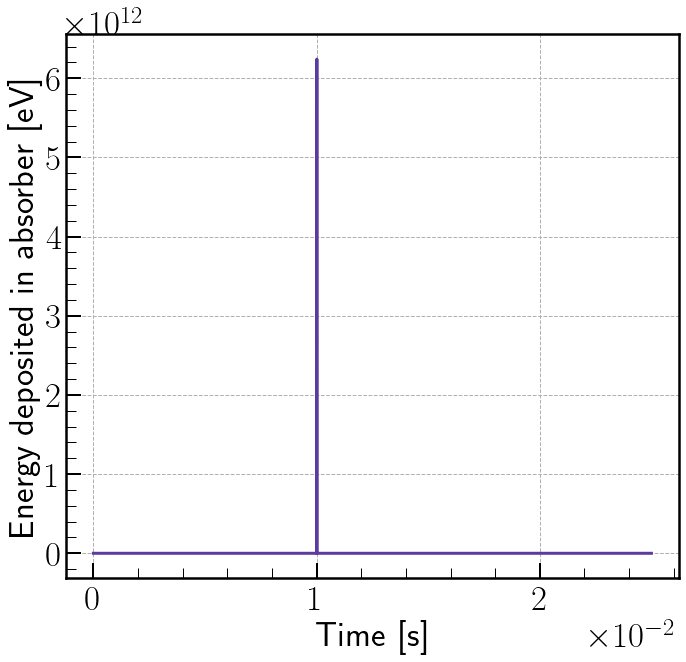

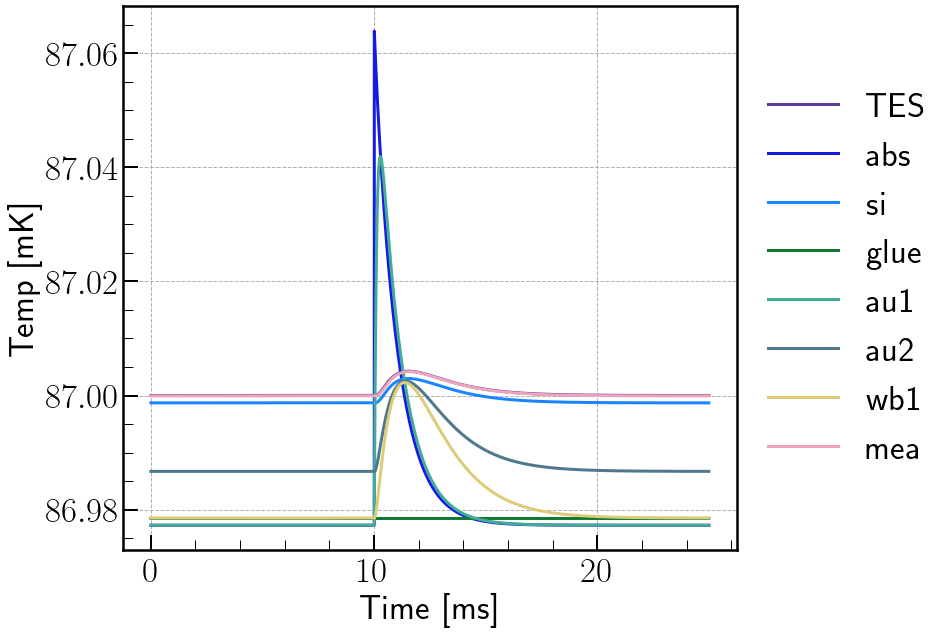

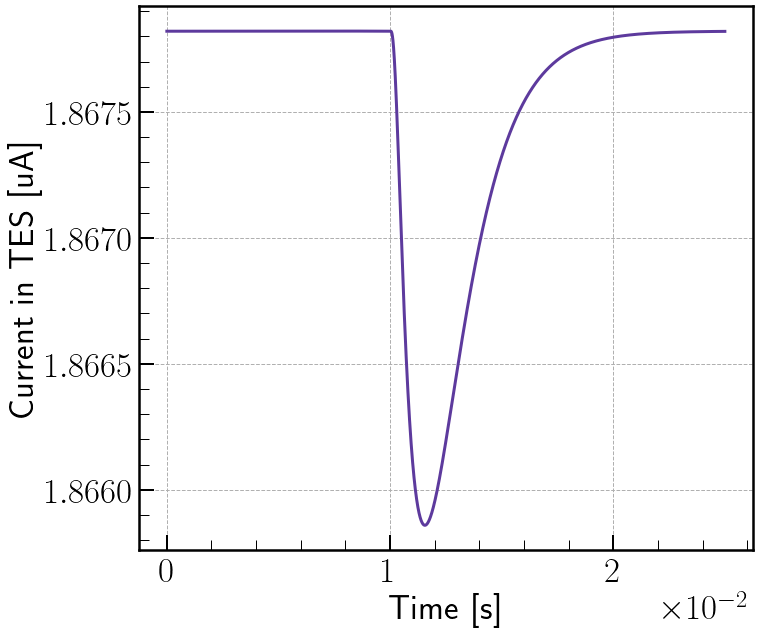

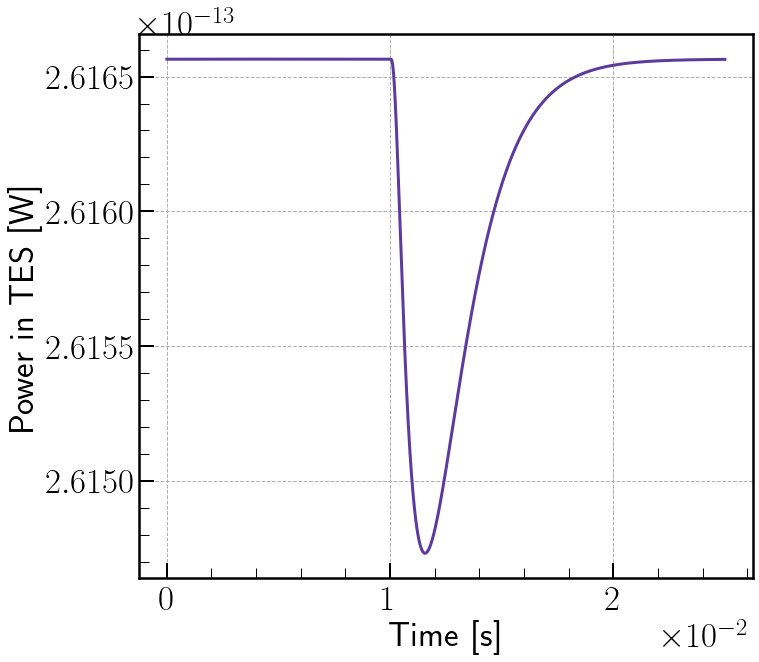

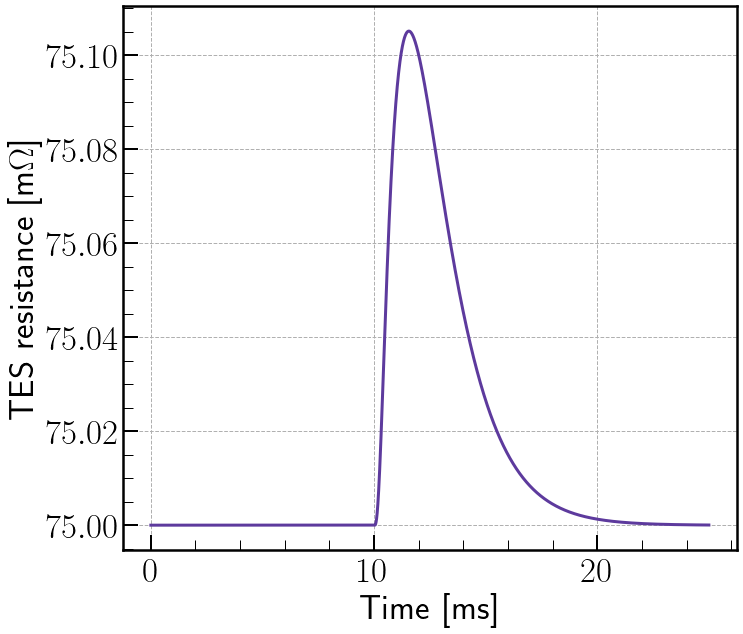

In [5]:
plt.plot(t_s,ev)
plt.ylabel("Energy deposited in absorber [eV]")
plt.xlabel("Time [s]")
plt.show()

for c in temps:
    if c=="bath":
        continue
    plt.plot(t_s*1E3,[t*1E3 for t in temps[c]],label=c)
plt.ylabel("Temp [mK]")
plt.xlabel("Time [ms]")
plt.legend(loc = 'center left',bbox_to_anchor = [1,0.5])
plt.show()

plt.plot(t_s,[i*1E6 for i in tes_i])
plt.ylabel("Current in TES [uA]")
plt.xlabel("Time [s]")
plt.show()

plt.plot(t_s,tes_p)
plt.ylabel("Power in TES [W]")
plt.xlabel("Time [s]")
plt.show()

plt.plot(t_s*1E3,[r*1E3 for r in tes_r])
plt.ylabel(r"TES resistance [m$\Omega$]")
plt.xlabel("Time [ms]")
# plt.yscale("log")
plt.show()
